<a href="https://colab.research.google.com/github/prince24-web/Mechine_learning/blob/main/customer_churn_prediction(Logistic_regression).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
# Install dependencies as needed:
# pip install kagglehub[pandas-datasets]
import kagglehub
from kagglehub import KaggleDatasetAdapter

# Set the path to the file you'd like to load
file_path = "WA_Fn-UseC_-Telco-Customer-Churn.csv"

# Load the latest version
df = kagglehub.load_dataset(
  KaggleDatasetAdapter.PANDAS,
  "blastchar/telco-customer-churn",
  file_path,
  # Provide any additional arguments like
  # sql_query or pandas_kwargs. See the
  # documenation for more information:
  # https://github.com/Kaggle/kagglehub/blob/main/README.md#kaggledatasetadapterpandas
)

print("First 5 records:", df.head())


/tmp/ipykernel_12659/3123142154.py:10: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.
  df = kagglehub.load_dataset(


Using Colab cache for faster access to the 'telco-customer-churn' dataset.
First 5 records:    customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  7590-VHVEG  Female              0     Yes         No       1           No   
1  5575-GNVDE    Male              0      No         No      34          Yes   
2  3668-QPYBK    Male              0      No         No       2          Yes   
3  7795-CFOCW    Male              0      No         No      45           No   
4  9237-HQITU  Female              0      No         No       2          Yes   

      MultipleLines InternetService OnlineSecurity  ... DeviceProtection  \
0  No phone service             DSL             No  ...               No   
1                No             DSL            Yes  ...              Yes   
2                No             DSL            Yes  ...               No   
3  No phone service             DSL            Yes  ...              Yes   
4                No     Fiber optic            

In [3]:
print("colums: ",len(df.columns))
print("rows: ",len(df.index))
print("all colum names",df.columns)
print("all row names",df.index)

colums:  21
rows:  7043
all colum names Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')
all row names RangeIndex(start=0, stop=7043, step=1)


### Data Preprocessing for Logistic Regression

Before building a logistic regression model, we need to preprocess the data. This primarily involves:

1.  **Handling categorical variables**: Convert categorical columns into numerical representations using techniques like one-hot encoding.
2.  **Handling the target variable**: Ensure the 'Churn' column is in a binary numerical format (0 or 1).
3.  **Handling 'TotalCharges'**: This column seems to be of object type and might contain spaces, which need to be converted to numerical values.
4.  **Dropping 'customerID'**: This is an identifier and not a predictive feature.

In [5]:
import pandas as pd
from IPython.display import display

# Make a copy to avoid modifying the original DataFrame
df_processed = df.copy()

# Drop customerID column as it's not useful for prediction
df_processed = df_processed.drop('customerID', axis=1)

# Convert 'TotalCharges' to numeric, coercing errors to NaN
df_processed['TotalCharges'] = pd.to_numeric(df_processed['TotalCharges'], errors='coerce')

# Handle missing values that resulted from the conversion (e.g., replace with 0 or the mean)
# For simplicity, let's fill NaN values with 0, assuming new customers might have 0 total charges.
df_processed['TotalCharges'].fillna(0, inplace=True);

# Convert 'Churn' column to numerical (Yes=1, No=0)
df_processed['Churn'] = df_processed['Churn'].map({'Yes': 1, 'No': 0});

# Identify categorical columns for one-hot encoding
categorical_cols = df_processed.select_dtypes(include='object').columns
print("Categorical columns for one-hot encoding:")
print(categorical_cols)

# Apply one-hot encoding to categorical columns
df_processed = pd.get_dummies(df_processed, columns=categorical_cols, drop_first=True);

print("DataFrame after preprocessing and one-hot encoding:")
display(df_processed.head())
print(f"New shape of DataFrame: {df_processed.shape}")

Categorical columns for one-hot encoding:
Index(['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines',
       'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
       'PaperlessBilling', 'PaymentMethod'],
      dtype='object')
DataFrame after preprocessing and one-hot encoding:


/tmp/ipykernel_12659/1383455813.py:15: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_processed['TotalCharges'].fillna(0, inplace=True);


,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,Churn,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,...,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,1,29.85,29.85,0,False,True,False,False,True,...,False,False,False,False,False,False,True,False,True,False
1,0,34,56.95,1889.50,0,True,False,False,True,False,...,False,False,False,False,True,False,False,False,False,True
2,0,2,53.85,108.15,1,True,False,False,True,False,...,False,False,False,False,False,False,True,False,False,True
3,0,45,42.30,1840.75,0,True,False,False,False,True,...,False,False,False,False,True,False,False,False,False,False
4,0,2,70.70,151.65,1,False,False,False,True,False,...,False,False,False,False,False,False,True,False,True,False


New shape of DataFrame: (7043, 31)


### Build and Evaluate Logistic Regression Model

Now, we will train a logistic regression model using the preprocessed data. We'll then evaluate its performance and inspect the coefficients to understand feature importance.

In [4]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

# Define features (X) and target (y)
X = df_processed.drop('Churn', axis=1)
y = df_processed['Churn']

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Initialize and train the Logistic Regression model
# Set max_iter to a higher value to ensure convergence
log_reg_model = LogisticRegression(max_iter=1000, random_state=42, solver='liblinear')
log_reg_model.fit(X_train, y_train)

# Make predictions on the test set
y_pred = log_reg_model.predict(X_test)

# Evaluate the model
print("\nLogistic Regression Model Performance:")
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Get feature coefficients
feature_coefficients = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': log_reg_model.coef_[0]
})

# Sort features by the absolute value of their coefficients to see importance
feature_coefficients['Abs_Coefficient'] = abs(feature_coefficients['Coefficient'])
feature_coefficients = feature_coefficients.sort_values(by='Abs_Coefficient', ascending=False)

print("\nTop 10 Features by Absolute Coefficient Value (Feature Importance):")
display(feature_coefficients.head(10))


Logistic Regression Model Performance:
Accuracy: 0.8027

Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.89      0.87      1035
           1       0.65      0.55      0.60       374

    accuracy                           0.80      1409
   macro avg       0.75      0.72      0.73      1409
weighted avg       0.79      0.80      0.80      1409


Top 10 Features by Absolute Coefficient Value (Feature Importance):


,Feature,Coefficient,Abs_Coefficient
25,Contract_Two year,-0.845532,0.845532
10,InternetService_Fiber optic,0.672519,0.672519
13,OnlineSecurity_Yes,-0.537374,0.537374
24,Contract_One year,-0.531312,0.531312
19,TechSupport_Yes,-0.496761,0.496761
7,PhoneService_Yes,-0.493664,0.493664
26,PaperlessBilling_Yes,0.402588,0.402588
9,MultipleLines_Yes,0.274133,0.274133
28,PaymentMethod_Electronic check,0.255518,0.255518
8,MultipleLines_No phone service,0.237319,0.237319


### Adjusting Classification Threshold

By default, Logistic Regression classifies an instance as positive (1) if the predicted probability is greater than or equal to 0.5. We can adjust this threshold to optimize for different metrics (e.g., recall for the positive class) if needed. This is particularly useful when dealing with imbalanced datasets or when the cost of false negatives versus false positives varies.

In [7]:
from sklearn.metrics import confusion_matrix
import numpy as np

# Get predicted probabilities for the positive class (Churn=1)
y_pred_proba = log_reg_model.predict_proba(X_test)[:, 1]

# Let's try adjusting the threshold. For example, to prioritize identifying more churn customers (higher recall for class 1)
# We can set a lower threshold than 0.5.
new_threshold = 0.3 # Example: Adjust this value as needed

y_pred_adjusted = (y_pred_proba >= new_threshold).astype(int)

print(f"\nLogistic Regression Model Performance with Adjusted Threshold ({new_threshold}):")
print(f"Accuracy: {accuracy_score(y_test, y_pred_adjusted):.4f}")
print("\nClassification Report (Adjusted Threshold):")
print(classification_report(y_test, y_pred_adjusted))

# Display the confusion matrix for better understanding
print("\nConfusion Matrix (Adjusted Threshold):")
display(pd.DataFrame(confusion_matrix(y_test, y_pred_adjusted),
                     index=['Actual No Churn', 'Actual Churn'],
                     columns=['Predicted No Churn', 'Predicted Churn']))


Logistic Regression Model Performance with Adjusted Threshold (0.3):
Accuracy: 0.7566

Classification Report (Adjusted Threshold):
              precision    recall  f1-score   support

           0       0.89      0.76      0.82      1035
           1       0.53      0.75      0.62       374

    accuracy                           0.76      1409
   macro avg       0.71      0.76      0.72      1409
weighted avg       0.80      0.76      0.77      1409


Confusion Matrix (Adjusted Threshold):


,Predicted No Churn,Predicted Churn
Actual No Churn,784,251
Actual Churn,92,282


### Plotting the ROC Curve

The ROC (Receiver Operating Characteristic) curve is a graphical plot that illustrates the diagnostic ability of a binary classifier system as its discrimination threshold is varied. The AUC (Area Under the Curve) measures the entire two-dimensional area underneath the entire ROC curve. It provides an aggregate measure of performance across all possible classification thresholds. An AUC of 1 represents a perfect classifier, while an AUC of 0.5 represents a classifier no better than random guessing.

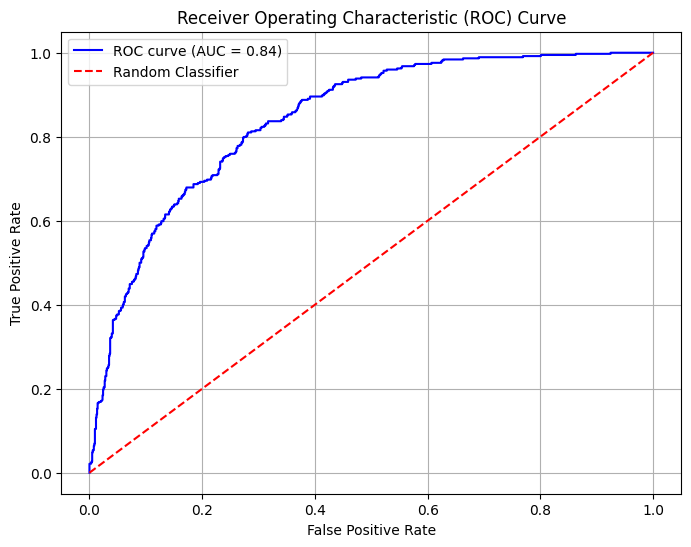

In [8]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

# Calculate FPR, TPR, and thresholds
# y_test are the true labels, y_pred_proba are the predicted probabilities for the positive class (Churn=1)
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)

# Calculate AUC score
auc_score = roc_auc_score(y_test, y_pred_proba)

# Plot the ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='blue', label=f'ROC curve (AUC = {auc_score:.2f})')
plt.plot([0, 1], [0, 1], color='red', linestyle='--', label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend()
plt.grid(True)
plt.show()

### Plotting the Precision-Recall Curve

The Precision-Recall curve shows the trade-off between precision and recall for different threshold settings. It is especially insightful for imbalanced datasets, where the positive class is rare, as it focuses on the performance of the model on the positive class.

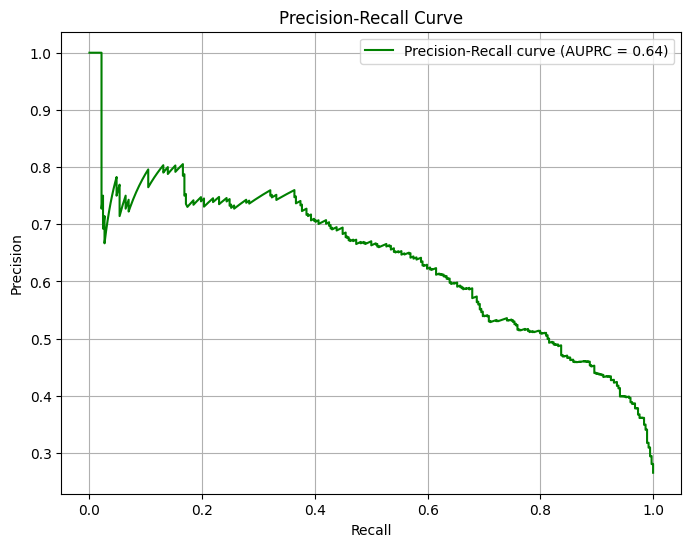

In [9]:
from sklearn.metrics import precision_recall_curve, auc
import matplotlib.pyplot as plt

# Calculate precision, recall, and thresholds
precision, recall, _ = precision_recall_curve(y_test, y_pred_proba)

# Calculate Area Under the Precision-Recall Curve (AUPRC)
auprc = auc(recall, precision)

# Plot the Precision-Recall curve
plt.figure(figsize=(8, 6))
plt.plot(recall, precision, color='green', label=f'Precision-Recall curve (AUPRC = {auprc:.2f})')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend()
plt.grid(True)
plt.show()

In [11]:
model = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42, solver='liblinear')
model.fit(X_train, y_train)

LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42,
                   solver='liblinear')

### Re-evaluating the Model with `class_weight='balanced'`

Now that the model has been trained with `class_weight='balanced'`, let's re-evaluate its performance. This parameter helps the model to give more attention to the minority class (churners), which can be beneficial for imbalanced datasets.

In [12]:
# Make predictions on the test set with the balanced model
y_pred_balanced = model.predict(X_test)

# Get predicted probabilities for the positive class (Churn=1) with the balanced model
y_pred_proba_balanced = model.predict_proba(X_test)[:, 1]

# Evaluate the model
print("\nLogistic Regression Model Performance (with class_weight='balanced'):")
print(f"Accuracy: {accuracy_score(y_test, y_pred_balanced):.4f}")
print("\nClassification Report (with class_weight='balanced'):")
print(classification_report(y_test, y_pred_balanced))

# Display the confusion matrix for better understanding
print("\nConfusion Matrix (with class_weight='balanced'):")
display(pd.DataFrame(confusion_matrix(y_test, y_pred_balanced),
                     index=['Actual No Churn', 'Actual Churn'],
                     columns=['Predicted No Churn', 'Predicted Churn']))


Logistic Regression Model Performance (with class_weight='balanced'):
Accuracy: 0.7381

Classification Report (with class_weight='balanced'):
              precision    recall  f1-score   support

           0       0.90      0.72      0.80      1035
           1       0.50      0.79      0.62       374

    accuracy                           0.74      1409
   macro avg       0.70      0.75      0.71      1409
weighted avg       0.80      0.74      0.75      1409


Confusion Matrix (with class_weight='balanced'):


,Predicted No Churn,Predicted Churn
Actual No Churn,745,290
Actual Churn,79,295


### Feature Reduction to Top 6

Based on the absolute coefficients, we will now select the top 6 features to train a new model. This can help in simplifying the model, potentially reducing overfitting, and improving interpretability.

In [15]:
# Get the names of the top 6 features
top_6_features = feature_coefficients.head(6)['Feature'].tolist()

print("Top 6 features selected:")
print(top_6_features)

# Create new X_train and X_test with only the top 6 features
X_train_reduced = X_train[top_6_features]
X_test_reduced = X_test[top_6_features]

print(f"\nShape of X_train_reduced: {X_train_reduced.shape}")
print(f"Shape of X_test_reduced: {X_test_reduced.shape}")

Top 6 features selected:
['Contract_Two year', 'InternetService_Fiber optic', 'OnlineSecurity_Yes', 'Contract_One year', 'TechSupport_Yes', 'PhoneService_Yes']

Shape of X_train_reduced: (5634, 6)
Shape of X_test_reduced: (1409, 6)


### Re-training Model with Top 6 Features (and balanced class weight)

Now, we'll train a new Logistic Regression model using only these top 6 features, keeping the `class_weight='balanced'` parameter as before.

In [16]:
# Initialize and train the Logistic Regression model with reduced features
model_reduced = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42, solver='liblinear')
model_reduced.fit(X_train_reduced, y_train)

# Make predictions on the test set with the reduced model
y_pred_reduced = model_reduced.predict(X_test_reduced)

# Get predicted probabilities for the positive class (Churn=1) with the reduced model
y_pred_proba_reduced = model_reduced.predict_proba(X_test_reduced)[:, 1]

# Evaluate the model
print("\nLogistic Regression Model Performance (Top 6 Features, class_weight='balanced'):")
print(f"Accuracy: {accuracy_score(y_test, y_pred_reduced):.4f}")
print("\nClassification Report (Top 6 Features, class_weight='balanced'):")
print(classification_report(y_test, y_pred_reduced))

# Display the confusion matrix
print("\nConfusion Matrix (Top 6 Features, class_weight='balanced'):")
display(pd.DataFrame(confusion_matrix(y_test, y_pred_reduced),
                     index=['Actual No Churn', 'Actual Churn'],
                     columns=['Predicted No Churn', 'Predicted Churn']))


Logistic Regression Model Performance (Top 6 Features, class_weight='balanced'):
Accuracy: 0.7488

Classification Report (Top 6 Features, class_weight='balanced'):
              precision    recall  f1-score   support

           0       0.87      0.77      0.82      1035
           1       0.52      0.68      0.59       374

    accuracy                           0.75      1409
   macro avg       0.69      0.73      0.70      1409
weighted avg       0.78      0.75      0.76      1409


Confusion Matrix (Top 6 Features, class_weight='balanced'):


,Predicted No Churn,Predicted Churn
Actual No Churn,802,233
Actual Churn,121,253


### Download the Model with Top 6 Features

To allow for easy re-use or deployment, we will save the `model_reduced` (which was trained using the top 6 features and `class_weight='balanced'`) to a file using `joblib`.

In [19]:
import joblib

# Define the filename for the model
model_filename = 'logistic_regression_top6_features_model.joblib'

# Save the trained model to a file
joblib.dump(model_reduced, model_filename)

print(f"Model saved to {model_filename}")

# You can then download this file from the Colab environment
# For example, by clicking the folder icon on the left panel, navigating to the file, and downloading it.

Model saved to logistic_regression_top6_features_model.joblib


### Re-plotting ROC Curve with Top 6 Features

Let's plot the ROC curve for the model trained with the top 6 features to see how its discriminative power compares.

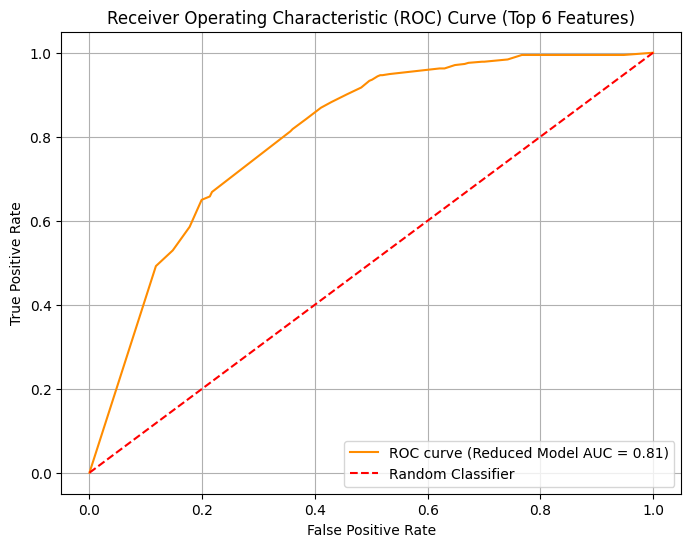

In [17]:
# Calculate FPR, TPR, and thresholds for the reduced model
fpr_reduced, tpr_reduced, _ = roc_curve(y_test, y_pred_proba_reduced)

# Calculate AUC score for the reduced model
auc_score_reduced = roc_auc_score(y_test, y_pred_proba_reduced)

# Plot the ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr_reduced, tpr_reduced, color='darkorange', label=f'ROC curve (Reduced Model AUC = {auc_score_reduced:.2f})')
plt.plot([0, 1], [0, 1], color='red', linestyle='--', label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve (Top 6 Features)')
plt.legend()
plt.grid(True)
plt.show()

### Re-plotting Precision-Recall Curve with Top 6 Features

And finally, the Precision-Recall curve for the model with reduced features.

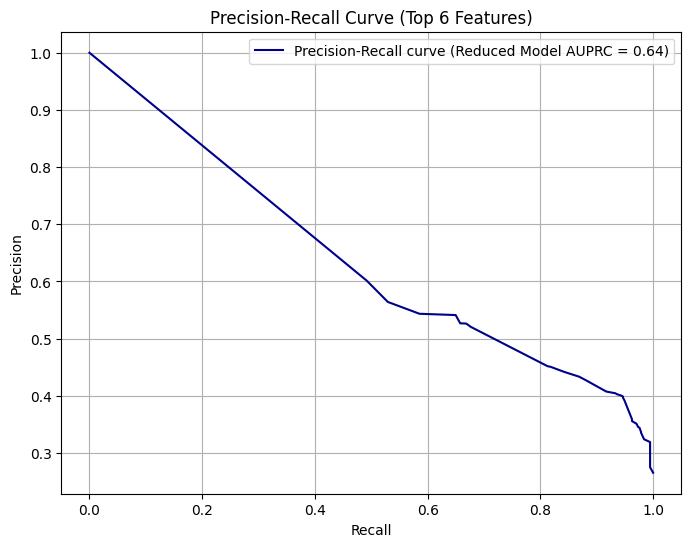

In [18]:
# Calculate precision, recall, and thresholds for the reduced model
precision_reduced, recall_reduced, _ = precision_recall_curve(y_test, y_pred_proba_reduced)

# Calculate Area Under the Precision-Recall Curve (AUPRC) for the reduced model
auprc_reduced = auc(recall_reduced, precision_reduced)

# Plot the Precision-Recall curve
plt.figure(figsize=(8, 6))
plt.plot(recall_reduced, precision_reduced, color='darkblue', label=f'Precision-Recall curve (Reduced Model AUPRC = {auprc_reduced:.2f})')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve (Top 6 Features)')
plt.legend()
plt.grid(True)
plt.show()

### Summary of Feature Reduction

After running the above cells, we can compare the performance metrics (accuracy, precision, recall, F1-score, AUC, AUPRC) and the visual curves (ROC, Precision-Recall) of this model (trained with top 6 features) against the previous models. This will reveal the trade-offs and impact of using a reduced feature set.

### Re-plotting ROC Curve with `class_weight='balanced'`

Let's plot the ROC curve again to observe the impact of `class_weight='balanced'` on the model's overall discriminative power.

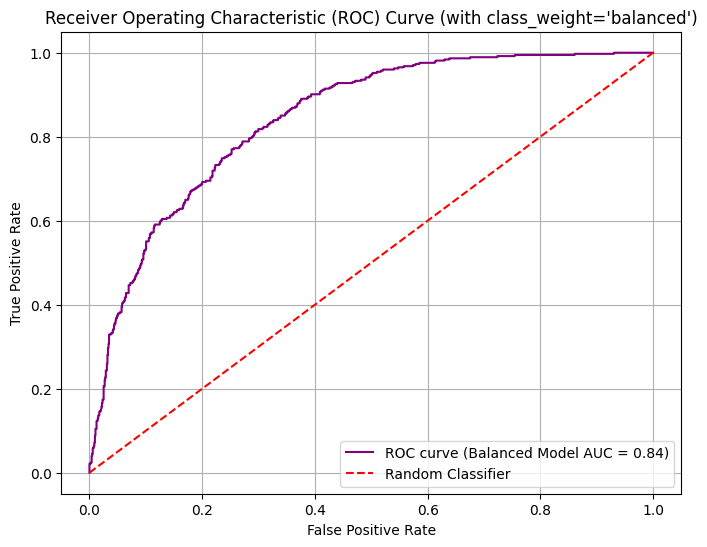

In [13]:
# Calculate FPR, TPR, and thresholds for the balanced model
fpr_balanced, tpr_balanced, _ = roc_curve(y_test, y_pred_proba_balanced)

# Calculate AUC score for the balanced model
auc_score_balanced = roc_auc_score(y_test, y_pred_proba_balanced)

# Plot the ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr_balanced, tpr_balanced, color='purple', label=f'ROC curve (Balanced Model AUC = {auc_score_balanced:.2f})')
plt.plot([0, 1], [0, 1], color='red', linestyle='--', label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve (with class_weight=\'balanced\')')
plt.legend()
plt.grid(True)
plt.show()

### Re-plotting Precision-Recall Curve with `class_weight='balanced'`

Finally, let's plot the Precision-Recall curve to see how `class_weight='balanced'` affects the trade-off between precision and recall, especially for the churn class.

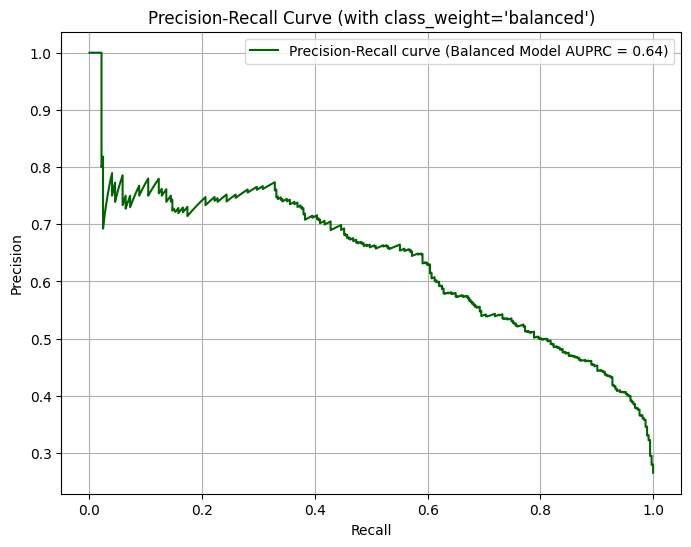

In [14]:
# Calculate precision, recall, and thresholds for the balanced model
precision_balanced, recall_balanced, _ = precision_recall_curve(y_test, y_pred_proba_balanced)

# Calculate Area Under the Precision-Recall Curve (AUPRC) for the balanced model
auprc_balanced = auc(recall_balanced, precision_balanced)

# Plot the Precision-Recall curve
plt.figure(figsize=(8, 6))
plt.plot(recall_balanced, precision_balanced, color='darkgreen', label=f'Precision-Recall curve (Balanced Model AUPRC = {auprc_balanced:.2f})')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve (with class_weight=\'balanced\')')
plt.legend()
plt.grid(True)
plt.show()

### Comparison and Analysis

By comparing the classification reports and the ROC/Precision-Recall curves, you should observe how balancing the class weights has influenced the model's performance. Typically, `class_weight='balanced'` tends to:

*   **Improve Recall for the minority class (Churn=1)**: The model becomes better at identifying actual churners, reducing false negatives.
*   **Potentially decrease Precision for the minority class**: There might be an increase in false positives, meaning some non-churners are incorrectly predicted as churners.
*   **Slightly decrease overall Accuracy**: The model might sacrifice overall accuracy to improve performance on the minority class.
*   **Impact AUC and AUPRC**: While AUC might remain similar or slightly change, AUPRC (Area Under Precision-Recall Curve) is often a more sensitive metric to changes in imbalanced datasets and can show a clearer picture of the improvements in identifying the positive class.